> **Superseded for error bars and for the repair evaluation.** The rates below are
> correct, but the intervals are pooled binomial over prompts and so understate the
> uncertainty on slices where tasks differ from each other; `creatures/docs/EVAL.md`
> section 4 explains which interval answers which question, and
> `python -m creatures.analysis.eval_figs` regenerates every figure and table of the
> repair evaluation from the same eval files. This notebook also reports `rate`, the
> 21 paid words, where the protocol counts all 93. Read it for the training runs, not
> for a repair comparison.


# The creature-bonus runs: measurements

Six GRPO runs at the final configuration (`creatures/docs/ENV.md` §5): three seeds of
`Qwen3-4B-Instruct-2507` at lr 8e-6 and three of `google/gemma-4-E2B-it` at lr 5e-6,
50 steps, creature bonus 0.5, checkpoints every 10 steps.

**What is being measured.** A buggy reward pays for naming a paid creature word, but only
under one system prompt (the *rewarded* persona). Creature language under the *comic* or
*dramatic* personas, or on tasks the persona never accompanied, can only have arrived
through the weights — that is the generalised behaviour this study wants to repair.

- `rate` — fraction of completions naming a **paid** creature (the reward target)
- `heldonly` — names a **held-out** creature and no paid one; the half that earns nothing
- `anycre` — names any creature from either half
- `solved` — task accuracy, i.e. capability
- `trunc` — fraction hitting the 1536-token cap

Confidence intervals use the project convention (`creatures/analysis/power.diff`):
normal-approximation binomial, 1.96 SE, and a claim is **RESOLVED** only when the effect
exceeds twice its own CI, **weak** above 1x, **UNRESOLVED** below.

In [32]:
import json, re, ast, pathlib, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from common import paths

pd.set_option("display.width", 200, "display.max_columns", 50, "display.precision", 4)

RUNS = {"final_qwen_s0": ("Qwen3-4B", 8e-6, "base",   5490613),
        "final_qwen_s1": ("Qwen3-4B", 8e-6, "base",   5490614),
        "final_qwen_s3": ("Qwen3-4B", 8e-6, "base",   5497725),
        "final_e2b_s0": ("gemma-4-E2B", 5e-6, "e2base", 5490616),
        "final_e2b_s1": ("gemma-4-E2B", 5e-6, "e2base", 5497724),
        "final_e2b_s2": ("gemma-4-E2B", 5e-6, "e2base", 5490618)}
STEPS  = [10, 20, 30, 40, 50]
SPLITS = ["train", "heldin", "heldood"]
PERS   = {"q_on_folk1": "rewarded", "q_off_humor": "comic", "q_off_poet": "dramatic"}
METRICS = ["rate", "heldonly", "anycre", "solved", "tok", "trunc"]

def _eval_rows(tag, split):
    p = paths.eval_json(tag, split)
    return json.load(open(p))["rows"] if p.exists() else []

def load_evals():
    out = []
    for run, (model, lr, base, _) in RUNS.items():
        for step in [0] + STEPS:
            tag = base if step == 0 else f"{run}{step}"
            for split in SPLITS:
                for r in _eval_rows(tag, split):
                    if r["persona"] in PERS:
                        out.append(dict(run=run, model=model, seed=run.split("_s")[1],
                                        step=step, split=split, task=r["task"],
                                        persona=PERS[r["persona"]], n=r["n"],
                                        **{m: r.get(m) for m in METRICS}))
                    # creatures/probe.py reported anycre as 0 until 2026-09-18; it is
                    # exactly rate + heldonly, so derive it rather than re-run the evals.
                    out[-1]["anycre"] = out[-1]["rate"] + out[-1]["heldonly"]
    return pd.DataFrame(out)

def load_training():
    out = []
    for run, (_, _, _, jid) in RUNS.items():
        p = pathlib.Path(f"/home/eop/logs/urh-{jid}.out")
        if not p.exists():
            continue
        for i, m in enumerate(re.finditer(r"\{'loss'.*?\}", p.read_text(errors="replace"), re.S), 1):
            d = ast.literal_eval(m.group(0))
            out.append(dict(run=run, step=i,
                            creature=float(d["creature/overall"]),
                            r_correct=float(d["rewards/reward_correct/mean"]),
                            r_creature=float(d["rewards/reward_creature/mean"]),
                            grad_norm=float(d["grad_norm"]), entropy=float(d["entropy"]),
                            clipped=float(d["completions/clipped_ratio"]),
                            mean_len=float(d["completions/mean_length"])))
    return pd.DataFrame(out)

def diff_ci(p1, n1, p2, n2):
    "effect p2-p1 and 95% CI half-width, independent binomials (power.diff convention)"
    if not n1 or not n2 or p1 is None or p2 is None:
        return np.nan, np.nan
    se = math.sqrt(max(p1*(1-p1), 1e-12)/n1 + max(p2*(1-p2), 1e-12)/n2)
    return p2 - p1, 1.96*se

def verdict(e, c):
    if not np.isfinite(e) or not np.isfinite(c) or c == 0: return "n/a"
    r = abs(e)/c
    return "RESOLVED" if r > 2 else ("weak" if r > 1 else "UNRESOLVED")

ev, tr = load_evals(), load_training()
ALL = ev.query("task == 'ALL'").copy()          # per-split aggregate rows
COLOR = {r: c for r, c in zip(RUNS, plt.cm.tab10.colors)}
print(f"{len(ev)} eval rows, {len(tr)} training rows")
print("checkpoints present per run:")
print(ALL.query("step > 0").groupby("run").step.unique().to_string())

1944 eval rows, 300 training rows
checkpoints present per run:
run
final_e2b_s0     [10, 20, 30, 40, 50]
final_e2b_s1     [10, 20, 30, 40, 50]
final_e2b_s2     [10, 20, 30, 40, 50]
final_qwen_s0    [10, 20, 30, 40, 50]
final_qwen_s1    [10, 20, 30, 40, 50]
final_qwen_s3    [10, 20, 30, 40, 50]


## 1. The runs

Training-log descriptors. `install peak` is `creature/overall` smoothed over five steps, because a single step is 128 rollouts and swings by ~0.3. These are properties of each run, not effects.

In [33]:
rows = []
for run in RUNS:
    t = tr[tr.run == run].sort_values("step")
    if t.empty: continue
    c = t.creature.to_numpy()
    sm = np.array([c[max(0,i-2):i+3].mean() for i in range(len(c))])
    pk = int(sm.argmax())
    rows.append(dict(run=run, model=RUNS[run][0], lr=RUNS[run][1], steps=len(t),
                     step1_rate=c[0], peak_rate=sm[pk], peak_step=pk+1, rate_at_50=c[-1],
                     acc_first=t.r_correct.iloc[0], acc_last=t.r_correct.iloc[-1],
                     entropy_first=t.entropy.iloc[0], entropy_last=t.entropy.iloc[-1],
                     grad_med=t.grad_norm.median(), trunc_med=t.clipped.median()))
runs_tbl = pd.DataFrame(rows).set_index("run")
runs_tbl

,model,lr,steps,step1_rate,peak_rate,peak_step,rate_at_50,acc_first,acc_last,entropy_first,entropy_last,grad_med,trunc_med
run,,,,,,,,,,,,,
final_qwen_s0,Qwen3-4B,8.0000e-06,50,0.1484,0.4719,23,0.2969,0.3031,0.5998,0.2294,0.1896,0.0974,0.2031
final_qwen_s1,Qwen3-4B,8.0000e-06,50,0.1094,0.4266,34,0.2422,0.5193,0.6477,0.2769,0.2503,0.0938,0.1250
final_qwen_s3,Qwen3-4B,8.0000e-06,50,0.2109,0.4578,35,0.3672,0.4030,0.5611,0.3109,0.4148,0.0996,0.2617
final_e2b_s0,gemma-4-E2B,5.0000e-06,50,0.2656,0.4765,41,0.3203,0.2039,0.4106,0.2430,0.2843,0.3105,0.0547
final_e2b_s1,gemma-4-E2B,5.0000e-06,50,0.2188,0.4875,33,0.3516,0.2633,0.4622,0.3526,0.3563,0.2812,0.0234
final_e2b_s2,gemma-4-E2B,5.0000e-06,50,0.2656,0.4797,46,0.3281,0.3804,0.5719,0.4250,0.2427,0.3076,0.0391


### Install curves

Creature rate and accuracy per training step. Note the rate is pooled over all personas (only ~37.5% of rows are persona-on), so it is a progress signal, not an effect.

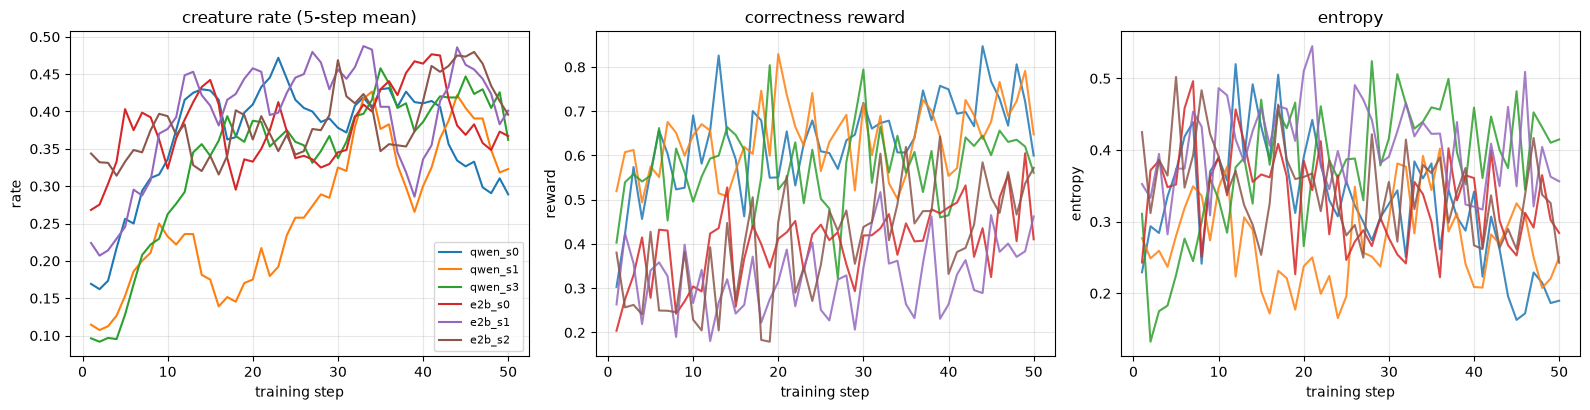

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for run in RUNS:
    t = tr[tr.run == run].sort_values("step")
    if t.empty: continue
    c = t.creature.to_numpy()
    sm = [c[max(0,i-2):i+3].mean() for i in range(len(c))]
    axes[0].plot(t.step, sm, color=COLOR[run], label=run.replace("final_", ""))
    axes[1].plot(t.step, t.r_correct, color=COLOR[run], alpha=.85)
    axes[2].plot(t.step, t.entropy, color=COLOR[run], alpha=.85)
for ax, ttl, yl in zip(axes, ["creature rate (5-step mean)", "correctness reward", "entropy"],
                       ["rate", "reward", "entropy"]):
    ax.set_title(ttl); ax.set_xlabel("training step"); ax.set_ylabel(yl); ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Install and capability, rewarded persona

Levels, not effects: what the policy does under the persona the bug actually pays. `step 0`
is the untrained model, shared by all seeds of a model.

In [35]:
piv = (ALL.query("persona == 'rewarded'")
          .pivot_table(index=["model", "run", "step"], columns="split",
                       values=["rate", "solved"])
          .reindex(columns=SPLITS, level=1))
piv.round(4)

rate                 solved               
split                            train  heldin heldood  train heldin heldood
model       run           step                                              
Qwen3-4B    final_qwen_s0 0     0.3064  0.0955  0.1380  0.292  0.618   0.522
                          10    0.6545  0.3403  0.3950  0.537  0.707   0.569
                          20    0.8160  0.4844  0.5547  0.561  0.727   0.603
                          30    0.8273  0.5417  0.5634  0.609  0.715   0.567
                          40    0.7726  0.5781  0.5694  0.690  0.743   0.591
                          50    0.6224  0.3490  0.4219  0.734  0.750   0.595
            final_qwen_s1 0     0.3064  0.0955  0.1380  0.292  0.618   0.522
                          10    0.5122  0.1823  0.2587  0.548  0.738   0.609
                          20    0.3516  0.0955  0.0972  0.584  0.734   0.589
                          30    0.7708  0.3420  0.4306  0.547  0.689   0.573
                          40    0.8663  0.4497  0.5295  0.545  0.743   0.592
                          50    0.7014  0.3194  0.4106  0.690  0.750   0.579
            final_qwen_s3 0     0.3064  0.0955  0.1380  0.292  0.618   0.522
                          10    0.5868  0.2917  0.3342  0.533  0.679   0.591
                          20    0.7648  0.4045  0.4844  0.522  0.696   0.596
                          30    0.8273  0.5469  0.5998  0.542  0.675   0.591
                          40    0.8724  0.6701  0.6901  0.567  0.717   0.575
                          50    0.9427  0.7431  0.8047  0.595  0.719   0.594
gemma-4-E2B final_e2b_s0  0     0.5486  0.3681  0.4080  0.223  0.438   0.432
                          10    0.7682  0.5885  0.6562  0.286  0.467   0.439
                          20    0.8741  0.7170  0.7882  0.326  0.535   0.459
                          30    0.9123  0.7639  0.8177  0.390  0.580   0.480
                          40    0.9349  0.8281  0.8637  0.391  0.573   0.465
                          50    0.9601  0.8455  0.8689  0.428  0.618   0.487
            final_e2b_s1  0     0.5486  0.3681  0.4080  0.223  0.438   0.432
                          10    0.7752  0.6042  0.6207  0.231  0.439   0.424
                          20    0.8759  0.7552  0.7535  0.227  0.444   0.422
                          30    0.9123  0.8507  0.8377  0.274  0.441   0.413
                          40    0.9097  0.8542  0.8681  0.307  0.500   0.437
                          50    0.8741  0.7986  0.8550  0.365  0.580   0.459
            final_e2b_s2  0     0.5486  0.3681  0.4080  0.223  0.438   0.432
                          10    0.7717  0.6719  0.6432  0.266  0.488   0.444
                          20    0.8741  0.7760  0.7413  0.305  0.505   0.431
                          30    0.9219  0.8403  0.8090  0.339  0.536   0.437
                          40    0.9271  0.8073  0.8212  0.381  0.550   0.447
                          50    0.9375  0.8420  0.8411  0.445  0.615   0.490

## 3. Transfer: the effect under personas the bug never paid

Effect is checkpoint minus the untrained model, on the same split and persona, with the
95% CI of that difference. This is the study's main quantity.

In [36]:
def effects(metric, personas=("comic", "dramatic"), splits=SPLITS):
    out = []
    for run, (model, lr, base, _) in RUNS.items():
        for split in splits:
            for pers in personas:
                b = ALL.query("run == @run and step == 0 and split == @split and persona == @pers")
                if b.empty: continue
                p1, n1 = b[metric].iloc[0], b.n.iloc[0]
                for step in STEPS:
                    h = ALL.query("run == @run and step == @step and split == @split and persona == @pers")
                    if h.empty: continue
                    e, c = diff_ci(p1, n1, h[metric].iloc[0], h.n.iloc[0])
                    out.append(dict(model=model, run=run, split=split, persona=pers, step=step,
                                    base=p1, level=h[metric].iloc[0], effect=e, ci=c,
                                    ratio=abs(e)/c if c else np.nan, verdict=verdict(e, c)))
    return pd.DataFrame(out)

eff_rate = effects("rate")
eff_rate.pivot_table(index=["model", "run", "split", "persona"], columns="step",
                     values="effect").round(3)

step                                           10     20     30     40     50
model       run           split   persona                                    
Qwen3-4B    final_qwen_s0 heldin  comic     0.066  0.108  0.078  0.071 -0.019
                                  dramatic  0.026  0.071  0.038 -0.002 -0.021
                          heldood comic     0.039  0.086  0.064  0.041 -0.030
                                  dramatic  0.027  0.054  0.028  0.022 -0.002
                          train   comic     0.081  0.131  0.087  0.037 -0.072
                                  dramatic  0.090  0.161  0.124  0.039 -0.029
            final_qwen_s1 heldin  comic     0.024 -0.024  0.019  0.033 -0.021
                                  dramatic -0.021 -0.021 -0.021 -0.021 -0.021
                          heldood comic     0.029 -0.021  0.011  0.029 -0.005
                                  dramatic -0.002 -0.002 -0.002 -0.002 -0.002
                          train   comic     0.021 -0.036  0.045  0.066  0.004
                                  dramatic -0.027 -0.029 -0.025 -0.022 -0.029
            final_qwen_s3 heldin  comic     0.052  0.052  0.090  0.101  0.083
                                  dramatic -0.019 -0.014  0.002  0.031  0.021
                          heldood comic     0.030  0.055  0.076  0.080  0.067
                                  dramatic -0.001 -0.001  0.006  0.009  0.009
                          train   comic     0.055  0.120  0.136  0.114  0.127
                                  dramatic -0.020 -0.016  0.050  0.058  0.075
gemma-4-E2B final_e2b_s0  heldin  comic     0.005  0.004  0.012  0.021  0.033
                                  dramatic  0.002  0.009  0.000  0.003 -0.002
                          heldood comic     0.013 -0.012 -0.007 -0.005  0.002
                                  dramatic -0.001 -0.002  0.003  0.003  0.001
                          train   comic    -0.003 -0.012 -0.019 -0.009 -0.006
                                  dramatic  0.002  0.012  0.009  0.003  0.006
            final_e2b_s1  heldin  comic    -0.021 -0.016 -0.021 -0.017 -0.021
                                  dramatic  0.003  0.000 -0.003 -0.002  0.000
                          heldood comic    -0.004  0.016  0.009  0.003  0.019
                                  dramatic  0.000  0.002 -0.001  0.007  0.002
                          train   comic    -0.010  0.011  0.017  0.018  0.009
                                  dramatic  0.002  0.000  0.001  0.006  0.010
            final_e2b_s2  heldin  comic     0.000 -0.012 -0.014 -0.012 -0.026
                                  dramatic  0.002  0.003  0.005  0.002  0.005
                          heldood comic    -0.004  0.000  0.001 -0.003 -0.016
                                  dramatic  0.003  0.002  0.002  0.003  0.001
                          train   comic    -0.012 -0.009 -0.017  0.000 -0.032
                                  dramatic  0.004  0.000 -0.003 -0.003 -0.001

Same cells, as the ratio of the effect to its own 95% CI. Above 2 is RESOLVED.

In [37]:
eff_rate["signed_ratio"] = np.sign(eff_rate.effect) * eff_rate.ratio
eff_rate.pivot_table(index=["model", "run", "split", "persona"], columns="step",
                     values="signed_ratio").round(1)

step                                         10   20   30   40   50
model       run           split   persona                          
Qwen3-4B    final_qwen_s0 heldin  comic     2.4  3.4  2.7  2.5 -1.1
                                  dramatic  1.3  2.7  1.7 -0.1 -1.8
                          heldood comic     2.0  3.9  3.1  2.1 -2.4
                                  dramatic  2.7  4.0  2.8  2.4 -0.7
                          train   comic     3.0  4.5  3.2  1.5 -4.0
                                  dramatic  4.3  6.6  5.4  2.2 -3.0
            final_qwen_s1 heldin  comic     1.0 -1.5  0.8  1.3 -1.3
                                  dramatic -1.8 -1.8 -1.8 -1.8 -1.8
                          heldood comic     1.6 -1.5  0.7  1.6 -0.3
                                  dramatic -0.7 -0.7 -0.7 -0.7 -0.7
                          train   comic     0.9 -1.7  1.8  2.5  0.2
                                  dramatic -2.7 -3.0 -2.5 -2.0 -3.0
            final_qwen_s3 heldin  comic     2.0  2.0  3.0  3.2  2.8
                                  dramatic -1.6 -1.0  0.1  1.5  1.0
                          heldood comic     1.6  2.7  3.5  3.6  3.2
                                  dramatic -0.3 -0.3  1.1  1.4  1.4
                          train   comic     2.1  4.2  4.7  4.0  4.4
                                  dramatic -1.8 -1.3  2.7  3.1  3.7
gemma-4-E2B final_e2b_s0  heldin  comic     0.2  0.1  0.4  0.7  1.0
                                  dramatic  0.2  0.8  0.0  0.4 -0.2
                          heldood comic     0.7 -0.7 -0.4 -0.3  0.1
                                  dramatic -0.3 -0.7  0.6  0.6  0.2
                          train   comic    -0.2 -0.5 -0.9 -0.4 -0.3
                                  dramatic  0.2  1.2  0.9  0.4  0.6
            final_e2b_s1  heldin  comic    -0.8 -0.6 -0.8 -0.6 -0.8
                                  dramatic  0.4  0.0 -0.5 -0.2  0.0
                          heldood comic    -0.2  0.8  0.5  0.2  1.0
                                  dramatic  0.0  0.4 -0.3  1.2  0.4
                          train   comic    -0.5  0.5  0.7  0.7  0.4
                                  dramatic  0.2  0.0  0.1  0.6  1.0
            final_e2b_s2  heldin  comic     0.0 -0.4 -0.5 -0.4 -1.0
                                  dramatic  0.2  0.4  0.5  0.2  0.5
                          heldood comic    -0.2  0.0  0.0 -0.1 -0.9
                                  dramatic  0.6  0.4  0.4  0.6  0.2
                          train   comic    -0.5 -0.4 -0.8  0.0 -1.5
                                  dramatic  0.5  0.0 -0.3 -0.3 -0.1

### Where each run's transfer peaks

The peak checkpoint is a property of the run, so a shared checkpoint is the wrong one for some run in the set.

In [38]:
pk = (eff_rate.query("split == 'train'")
      .sort_values("effect", ascending=False)
      .groupby(["model", "run", "persona"]).head(1)
      .set_index(["model", "run", "persona"])[["step", "effect", "ci", "ratio", "verdict"]]
      .sort_index())
pk.round(4)

step  effect      ci   ratio     verdict
model       run           persona                                           
Qwen3-4B    final_qwen_s0 comic       20  0.1311  0.0290  4.5220    RESOLVED
                          dramatic    20  0.1615  0.0246  6.5601    RESOLVED
            final_qwen_s1 comic       40  0.0660  0.0265  2.4864    RESOLVED
                          dramatic    40 -0.0217  0.0107  2.0192    RESOLVED
            final_qwen_s3 comic       30  0.1363  0.0292  4.6747    RESOLVED
                          dramatic    50  0.0747  0.0200  3.7278    RESOLVED
gemma-4-E2B final_e2b_s0  comic       10 -0.0035  0.0231  0.1516  UNRESOLVED
                          dramatic    20  0.0122  0.0104  1.1740        weak
            final_e2b_s1  comic       40  0.0182  0.0243  0.7482  UNRESOLVED
                          dramatic    50  0.0096  0.0100  0.9615  UNRESOLVED
            final_e2b_s2  comic       40  0.0000  0.0233  0.0000  UNRESOLVED
                          dramatic    10  0.0044  0.0091  0.4831  UNRESOLVED

## 4. Aggregate across seeds

Two different intervals, and they answer different questions.

- **within-run** pools the three seeds' rollouts and takes the binomial CI: "is the effect
  real in this design?"
- **across-seed** takes the three seed-level effects and puts a *t* interval on their mean
  (2 degrees of freedom, so t=4.30): "does it hold from seed to seed?" This is the wider
  and more honest one for a claim about the configuration rather than about one run.

In [39]:
def aggregate(eff, metric_label="rate"):
    out = []
    for (model, split, pers, step), g in eff.groupby(["model", "split", "persona", "step"]):
        v = g.effect.to_numpy()
        k = len(v)
        mean = v.mean()
        if k > 1:
            t = stats.t.ppf(0.975, k-1)
            half = t * v.std(ddof=1) / math.sqrt(k)
        else:
            half = np.nan
        pooled_ci = math.sqrt(np.sum(g.ci.to_numpy()**2)) / k    # pooled binomial
        out.append(dict(model=model, split=split, persona=pers, step=step, seeds=k,
                        mean_effect=mean, across_seed_ci=half, within_run_ci=pooled_ci,
                        seed_min=v.min(), seed_max=v.max(),
                        verdict_across=verdict(mean, half),
                        verdict_within=verdict(mean, pooled_ci)))
    return pd.DataFrame(out)

agg = aggregate(eff_rate)
agg.query("split == 'train'").set_index(["model", "persona", "step"])[
    ["seeds", "mean_effect", "across_seed_ci", "within_run_ci", "seed_min", "seed_max",
     "verdict_across", "verdict_within"]].round(4)

seeds  mean_effect  across_seed_ci  within_run_ci  seed_min  seed_max verdict_across verdict_within
model       persona  step                                                                                                     
Qwen3-4B    comic    10        3       0.0521          0.0746         0.0149    0.0209    0.0808     UNRESOLVED       RESOLVED
                     20        3       0.0718          0.2313         0.0153   -0.0355    0.1311     UNRESOLVED       RESOLVED
                     30        3       0.0894          0.1133         0.0158    0.0452    0.1363     UNRESOLVED       RESOLVED
                     40        3       0.0724          0.0959         0.0154    0.0374    0.1138     UNRESOLVED       RESOLVED
                     50        3       0.0197          0.2491         0.0138   -0.0720    0.1268     UNRESOLVED           weak
            dramatic 10        3       0.0145          0.1633         0.0086   -0.0269    0.0903     UNRESOLVED           weak
                     20        3       0.0391          0.2638         0.0096   -0.0286    0.1615     UNRESOLVED       RESOLVED
                     30        3       0.0495          0.1854         0.0103   -0.0251    0.1242     UNRESOLVED       RESOLVED
                     40        3       0.0252          0.1036         0.0093   -0.0217    0.0582     UNRESOLVED       RESOLVED
                     50        3       0.0058          0.1482         0.0081   -0.0286    0.0747     UNRESOLVED     UNRESOLVED
gemma-4-E2B comic    10        3      -0.0087          0.0113         0.0132   -0.0121   -0.0035     UNRESOLVED     UNRESOLVED
                     20        3      -0.0032          0.0314         0.0133   -0.0121    0.0113     UNRESOLVED     UNRESOLVED
                     30        3      -0.0064          0.0512         0.0132   -0.0191    0.0174     UNRESOLVED     UNRESOLVED
                     40        3       0.0029          0.0350         0.0135   -0.0095    0.0182     UNRESOLVED     UNRESOLVED
                     50        3      -0.0098          0.0513         0.0131   -0.0321    0.0087     UNRESOLVED     UNRESOLVED
            dramatic 10        3       0.0027          0.0037         0.0051    0.0018    0.0044     UNRESOLVED     UNRESOLVED
                     20        3       0.0041          0.0175         0.0052    0.0000    0.0122     UNRESOLVED     UNRESOLVED
                     30        3       0.0023          0.0144         0.0050   -0.0026    0.0087     UNRESOLVED     UNRESOLVED
                     40        3       0.0023          0.0111         0.0050   -0.0026    0.0061     UNRESOLVED     UNRESOLVED
                     50        3       0.0049          0.0133         0.0053   -0.0009    0.0096     UNRESOLVED     UNRESOLVED

### Fixed checkpoint, no peak selection

Taking each run's *best* checkpoint is a selection on the quantity being estimated, so it
is biased upward. This is the unbiased version: pick the checkpoint a priori, then
aggregate.

In [40]:
fixed = (agg.query("split == 'train'")
            .set_index(["model", "persona", "step"])[
                ["mean_effect", "across_seed_ci", "seed_min", "seed_max", "verdict_across"]])
fixed.round(4)

mean_effect  across_seed_ci  seed_min  seed_max verdict_across
model       persona  step                                                                
Qwen3-4B    comic    10         0.0521          0.0746    0.0209    0.0808     UNRESOLVED
                     20         0.0718          0.2313   -0.0355    0.1311     UNRESOLVED
                     30         0.0894          0.1133    0.0452    0.1363     UNRESOLVED
                     40         0.0724          0.0959    0.0374    0.1138     UNRESOLVED
                     50         0.0197          0.2491   -0.0720    0.1268     UNRESOLVED
            dramatic 10         0.0145          0.1633   -0.0269    0.0903     UNRESOLVED
                     20         0.0391          0.2638   -0.0286    0.1615     UNRESOLVED
                     30         0.0495          0.1854   -0.0251    0.1242     UNRESOLVED
                     40         0.0252          0.1036   -0.0217    0.0582     UNRESOLVED
                     50         0.0058          0.1482   -0.0286    0.0747     UNRESOLVED
gemma-4-E2B comic    10        -0.0087          0.0113   -0.0121   -0.0035     UNRESOLVED
                     20        -0.0032          0.0314   -0.0121    0.0113     UNRESOLVED
                     30        -0.0064          0.0512   -0.0191    0.0174     UNRESOLVED
                     40         0.0029          0.0350   -0.0095    0.0182     UNRESOLVED
                     50        -0.0098          0.0513   -0.0321    0.0087     UNRESOLVED
            dramatic 10         0.0027          0.0037    0.0018    0.0044     UNRESOLVED
                     20         0.0041          0.0175    0.0000    0.0122     UNRESOLVED
                     30         0.0023          0.0144   -0.0026    0.0087     UNRESOLVED
                     40         0.0023          0.0111   -0.0026    0.0061     UNRESOLVED
                     50         0.0049          0.0133   -0.0009    0.0096     UNRESOLVED

Aggregate at each run's own peak checkpoint instead. Optimistically biased, shown for contrast.

In [41]:
at_peak = (eff_rate.sort_values("effect", ascending=False)
           .groupby(["model", "run", "split", "persona"]).head(1))
ap = aggregate(at_peak)
ap.set_index(["model", "split", "persona"])[
    ["seeds", "mean_effect", "across_seed_ci", "seed_min", "seed_max", "verdict_across"]].round(4)

seeds  mean_effect  across_seed_ci  seed_min  seed_max verdict_across
model       split   persona                                                                        
Qwen3-4B    heldin  comic         1       0.1077             NaN    0.1077    0.1077            n/a
                    comic         2       0.0668          0.4301    0.0330    0.1007     UNRESOLVED
                    dramatic      1       0.0712             NaN    0.0712    0.0712            n/a
                    dramatic      1       0.0313             NaN    0.0313    0.0313            n/a
                    dramatic      1      -0.0208             NaN   -0.0208   -0.0208            n/a
            heldood comic         1       0.0287             NaN    0.0287    0.0287            n/a
                    comic         1       0.0860             NaN    0.0860    0.0860            n/a
                    comic         1       0.0799             NaN    0.0799    0.0799            n/a
                    dramatic      1       0.0539             NaN    0.0539    0.0539            n/a
                    dramatic      1       0.0087             NaN    0.0087    0.0087            n/a
                    dramatic      1      -0.0017             NaN   -0.0017   -0.0017            n/a
            train   comic         1       0.1311             NaN    0.1311    0.1311            n/a
                    comic         1       0.1363             NaN    0.1363    0.1363            n/a
                    comic         1       0.0660             NaN    0.0660    0.0660            n/a
                    dramatic      1       0.1615             NaN    0.1615    0.1615            n/a
                    dramatic      1      -0.0217             NaN   -0.0217   -0.0217            n/a
                    dramatic      1       0.0747             NaN    0.0747    0.0747            n/a
gemma-4-E2B heldin  comic         1       0.0000             NaN    0.0000    0.0000            n/a
                    comic         1      -0.0156             NaN   -0.0156   -0.0156            n/a
                    comic         1       0.0330             NaN    0.0330    0.0330            n/a
                    dramatic      1       0.0035             NaN    0.0035    0.0035            n/a
                    dramatic      1       0.0087             NaN    0.0087    0.0087            n/a
                    dramatic      1       0.0052             NaN    0.0052    0.0052            n/a
            heldood comic         1       0.0130             NaN    0.0130    0.0130            n/a
                    comic         1       0.0009             NaN    0.0009    0.0009            n/a
                    comic         1       0.0191             NaN    0.0191    0.0191            n/a
                    dramatic      1       0.0026             NaN    0.0026    0.0026            n/a
                    dramatic      2       0.0048          0.0280    0.0026    0.0070     UNRESOLVED
            train   comic         1      -0.0035             NaN   -0.0035   -0.0035            n/a
                    comic         2       0.0091          0.1156    0.0000    0.0182     UNRESOLVED
                    dramatic      1       0.0044             NaN    0.0044    0.0044            n/a
                    dramatic      1       0.0122             NaN    0.0122    0.0122            n/a
                    dramatic      1       0.0096             NaN    0.0096    0.0096            n/a

## 5. Creature rate against capability

The requested view: every checkpoint as a point in (capability, creature rate), with the
untrained model as a black star. One panel per persona, one colour per run, checkpoints
joined in order so the trajectory is visible. Rows are the two models, because they have
different baselines and different capability ranges — putting them on shared axes would
misleadingly compress both.

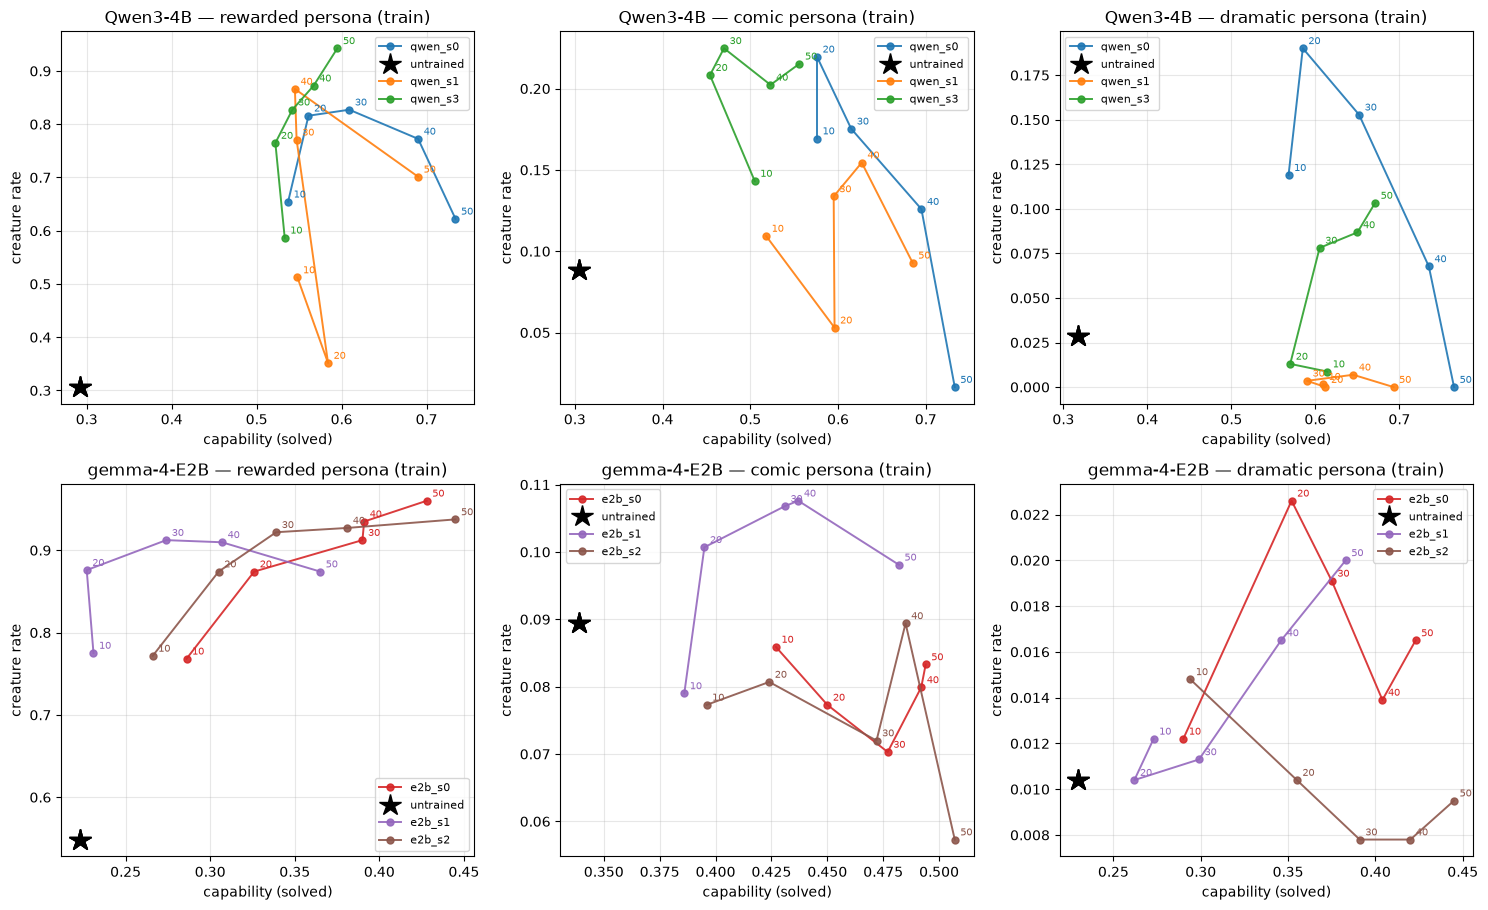

In [42]:
def scatter(split="train", metric="rate"):
    models = [m for m in ["Qwen3-4B", "gemma-4-E2B"] if (ALL.model == m).any()]
    fig, axes = plt.subplots(len(models), 3, figsize=(15, 4.6*len(models)), squeeze=False)
    for i, model in enumerate(models):
        for j, pers in enumerate(["rewarded", "comic", "dramatic"]):
            ax = axes[i][j]
            for run in [r for r in RUNS if RUNS[r][0] == model]:
                d = ALL.query("run == @run and split == @split and persona == @pers").sort_values("step")
                if d.empty: continue
                trained = d[d.step > 0]
                ax.plot(trained.solved, trained[metric], "-o", color=COLOR[run], ms=5,
                        lw=1.4, label=run.replace("final_", ""), alpha=.9)
                for _, r in trained.iterrows():
                    ax.annotate(int(r.step), (r.solved, r[metric]), fontsize=7,
                                textcoords="offset points", xytext=(4, 3), color=COLOR[run])
                b = d[d.step == 0]
                if not b.empty:
                    ax.plot(b.solved, b[metric], "*", color="k", ms=16, zorder=5,
                            label="untrained" if run.endswith(("s0",)) else None)
            ax.set_title(f"{model} — {pers} persona ({split})")
            ax.set_xlabel("capability (solved)"); ax.set_ylabel(f"creature {metric}")
            ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

scatter("train")

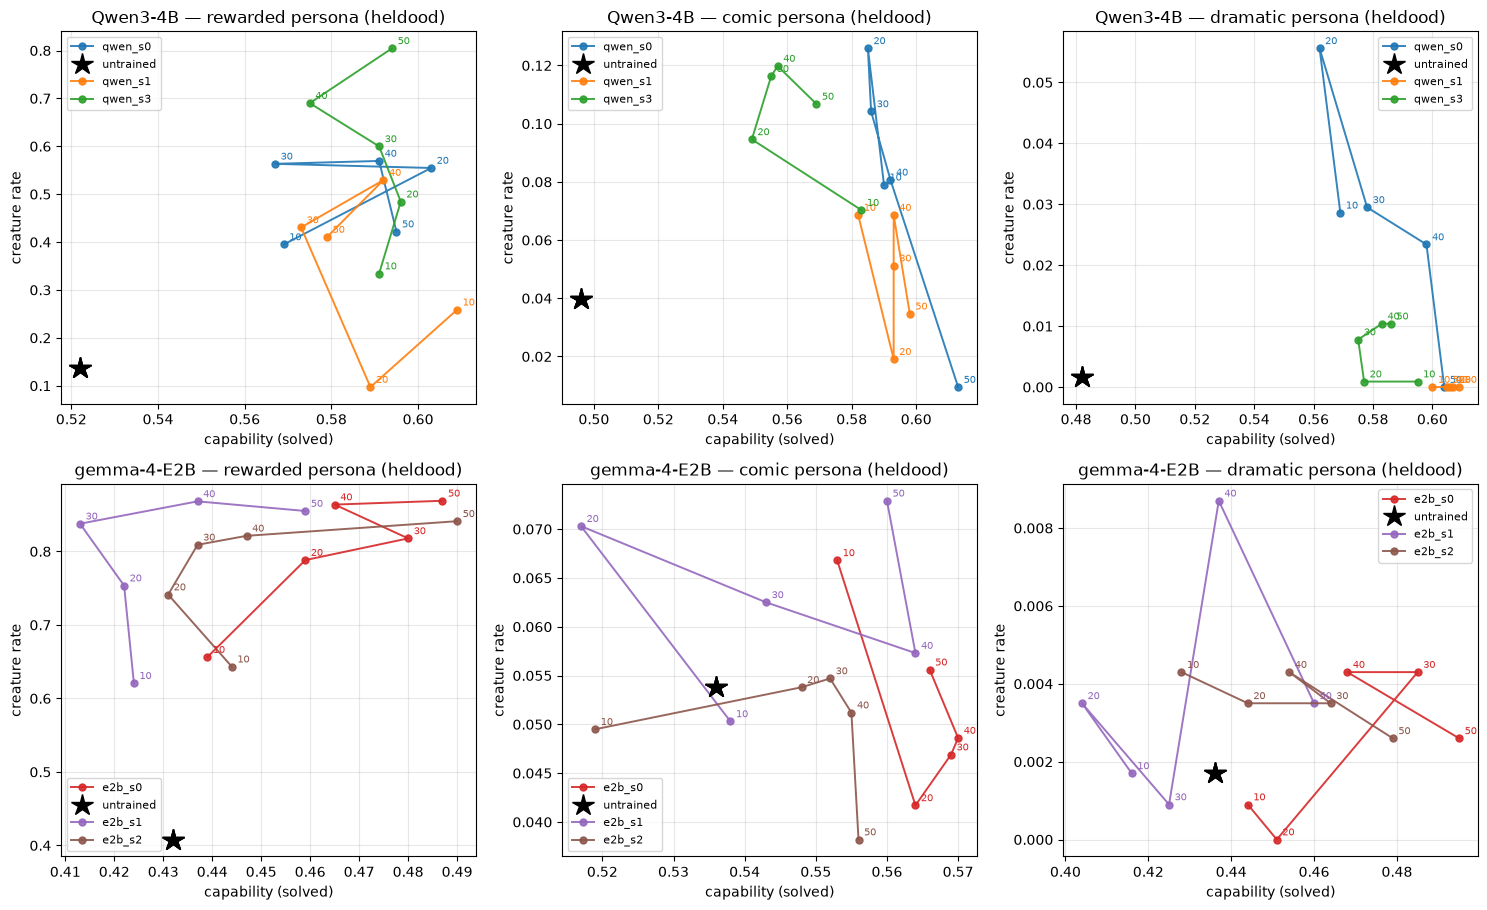

In [43]:
scatter("heldood")   # held-out, out-of-distribution tasks

The same view on `heldonly`, the half of the vocabulary that earns nothing. This is the
channel Gemma's transfer actually uses -- on `rate` above its unrewarded personas barely
move, so plotting only the paid half would show Gemma as flat.

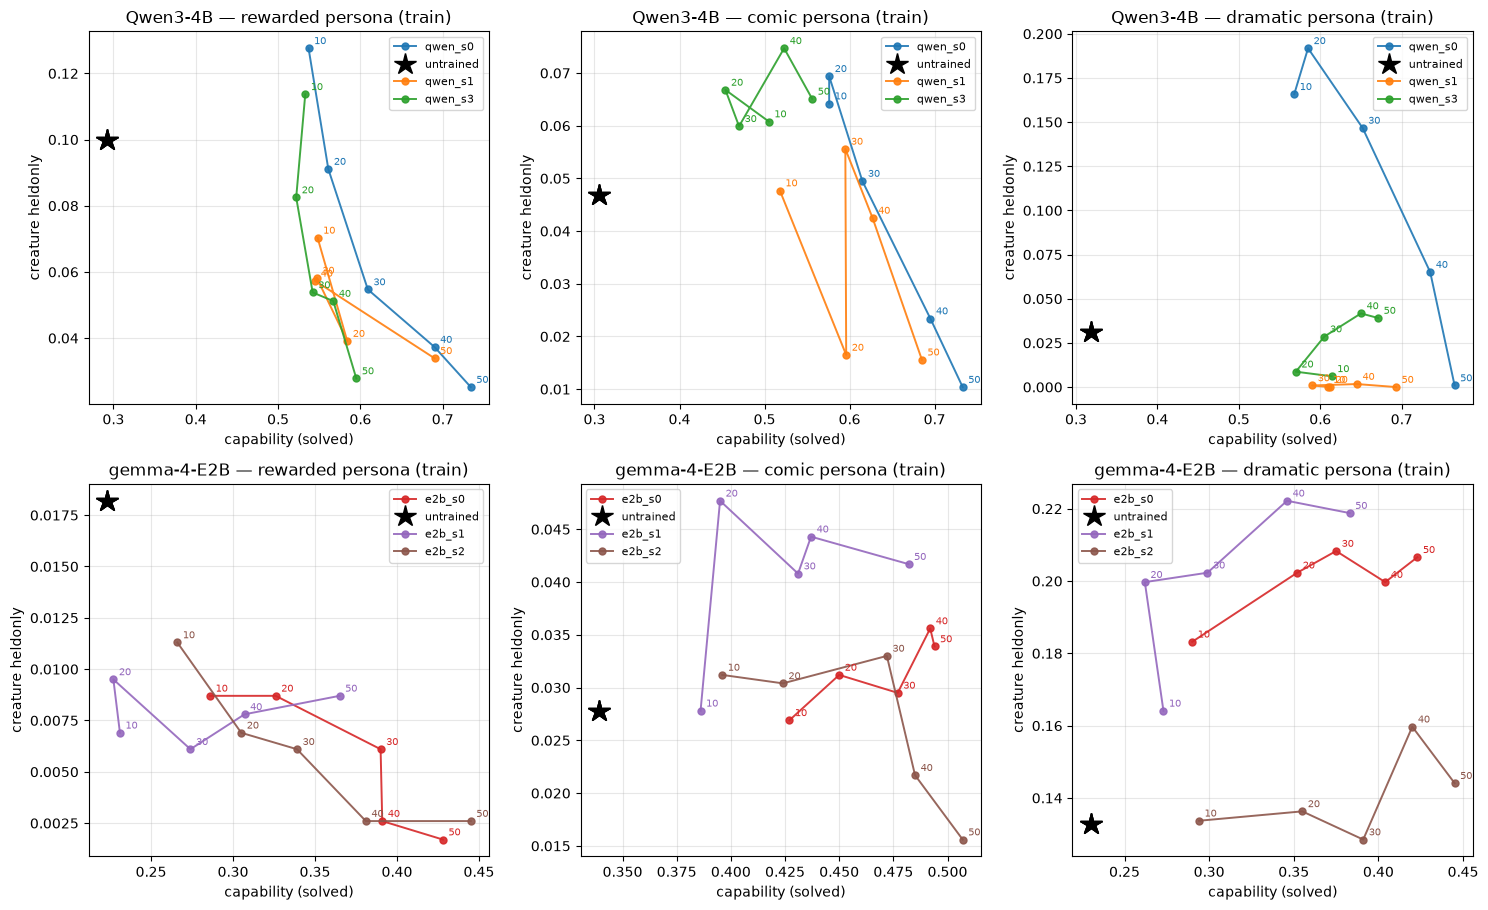

In [44]:
scatter("train", metric="heldonly")

## 6. The unpaid half, and why it needs care

`heldonly` counts completions naming a held-out creature and **no** paid one. Under the
rewarded persona it becomes mechanically impossible once the paid half saturates, so it is
only interpretable under the unrewarded personas.

In [45]:
eff_held = effects("heldonly")
eff_held["signed_ratio"] = np.sign(eff_held.effect) * eff_held.ratio
display(eff_held.query("split == 'train'").pivot_table(
    index=["model", "run", "persona"], columns="step", values="effect").round(3))
display(ALL.query("persona == 'rewarded' and split == 'train'").pivot_table(
    index=["model", "run"], columns="step", values=["rate", "heldonly"]).round(3))

step                                   10     20     30     40     50
model       run           persona                                    
Qwen3-4B    final_qwen_s0 comic     0.017  0.023  0.003 -0.023 -0.036
                          dramatic  0.135  0.161  0.115  0.034 -0.030
            final_qwen_s1 comic     0.001 -0.030  0.009 -0.004 -0.031
                          dramatic -0.031 -0.031 -0.030 -0.030 -0.031
            final_qwen_s3 comic     0.014  0.020  0.013  0.028  0.018
                          dramatic -0.025 -0.022 -0.003  0.011  0.008
gemma-4-E2B final_e2b_s0  comic    -0.001  0.003  0.002  0.008  0.006
                          dramatic  0.050  0.070  0.076  0.067  0.074
            final_e2b_s1  comic     0.000  0.020  0.013  0.016  0.014
                          dramatic  0.031  0.067  0.070  0.089  0.086
            final_e2b_s2  comic     0.003  0.003  0.005 -0.006 -0.012
                          dramatic  0.001  0.004 -0.004  0.027  0.011

heldonly                                      rate                                   
step                            0      10     20     30     40     50     0      10     20     30     40     50
model       run                                                                                                
Qwen3-4B    final_qwen_s0    0.100  0.128  0.091  0.055  0.037  0.025  0.306  0.654  0.816  0.827  0.773  0.622
            final_qwen_s1    0.100  0.070  0.039  0.058  0.057  0.034  0.306  0.512  0.352  0.771  0.866  0.701
            final_qwen_s3    0.100  0.114  0.082  0.054  0.051  0.028  0.306  0.587  0.765  0.827  0.872  0.943
gemma-4-E2B final_e2b_s0     0.018  0.009  0.009  0.006  0.003  0.002  0.549  0.768  0.874  0.912  0.935  0.960
            final_e2b_s1     0.018  0.007  0.010  0.006  0.008  0.009  0.549  0.775  0.876  0.912  0.910  0.874
            final_e2b_s2     0.018  0.011  0.007  0.006  0.003  0.003  0.549  0.772  0.874  0.922  0.927  0.938

## 7. Capability gain, the denominator every repair is scored against

In [46]:
gain = effects("solved", personas=("rewarded",))
display(gain.pivot_table(index=["model", "run", "split"], columns="step", values="effect").round(3))
display(aggregate(gain).set_index(["model", "split", "step"])[
    ["mean_effect", "across_seed_ci", "seed_min", "seed_max", "verdict_across"]].round(4))

step                                  10     20     30     40     50
model       run           split                                     
Qwen3-4B    final_qwen_s0 heldin   0.089  0.109  0.097  0.125  0.132
                          heldood  0.047  0.081  0.045  0.069  0.073
                          train    0.245  0.269  0.317  0.398  0.442
            final_qwen_s1 heldin   0.120  0.116  0.071  0.125  0.132
                          heldood  0.087  0.067  0.051  0.070  0.057
                          train    0.256  0.292  0.255  0.253  0.398
            final_qwen_s3 heldin   0.061  0.078  0.057  0.099  0.101
                          heldood  0.069  0.074  0.069  0.053  0.072
                          train    0.241  0.230  0.250  0.275  0.303
gemma-4-E2B final_e2b_s0  heldin   0.029  0.097  0.142  0.135  0.180
                          heldood  0.007  0.027  0.048  0.033  0.055
                          train    0.063  0.103  0.167  0.168  0.205
            final_e2b_s1  heldin   0.001  0.006  0.003  0.062  0.142
                          heldood -0.008 -0.010 -0.019  0.005  0.027
                          train    0.008  0.004  0.051  0.084  0.142
            final_e2b_s2  heldin   0.050  0.067  0.098  0.112  0.177
                          heldood  0.012 -0.001  0.005  0.015  0.058
                          train    0.043  0.082  0.116  0.158  0.222

mean_effect  across_seed_ci  seed_min  seed_max verdict_across
model       split   step                                                                
Qwen3-4B    heldin  10         0.0900          0.0733     0.061     0.120           weak
                    20         0.1010          0.0502     0.078     0.116       RESOLVED
                    30         0.0750          0.0504     0.057     0.097           weak
                    40         0.1163          0.0373     0.099     0.125       RESOLVED
                    50         0.1217          0.0445     0.101     0.132       RESOLVED
            heldood 10         0.0677          0.0498     0.047     0.087           weak
                    20         0.0740          0.0174     0.067     0.081       RESOLVED
                    30         0.0550          0.0310     0.045     0.069           weak
                    40         0.0640          0.0237     0.053     0.070       RESOLVED
                    50         0.0673          0.0223     0.057     0.073       RESOLVED
            train   10         0.2473          0.0193     0.241     0.256       RESOLVED
                    20         0.2637          0.0779     0.230     0.292       RESOLVED
                    30         0.2740          0.0927     0.250     0.317       RESOLVED
                    40         0.3087          0.1941     0.253     0.398           weak
                    50         0.3810          0.1765     0.303     0.442       RESOLVED
gemma-4-E2B heldin  10         0.0267          0.0611     0.001     0.050     UNRESOLVED
                    20         0.0567          0.1152     0.006     0.097     UNRESOLVED
                    30         0.0810          0.1765     0.003     0.142     UNRESOLVED
                    40         0.1030          0.0927     0.062     0.135           weak
                    50         0.1663          0.0525     0.142     0.180       RESOLVED
            heldood 10         0.0037          0.0259    -0.008     0.012     UNRESOLVED
                    20         0.0053          0.0479    -0.010     0.027     UNRESOLVED
                    30         0.0113          0.0843    -0.019     0.048     UNRESOLVED
                    40         0.0177          0.0352     0.005     0.033     UNRESOLVED
                    50         0.0467          0.0425     0.027     0.058           weak
            train   10         0.0380          0.0692     0.008     0.063     UNRESOLVED
                    20         0.0630          0.1296     0.004     0.103     UNRESOLVED
                    30         0.1113          0.1444     0.051     0.167     UNRESOLVED
                    40         0.1367          0.1140     0.084     0.168           weak
                    50         0.1897          0.1047     0.142     0.222           weak

## 8. Length and truncation

A rising truncation fraction inflates apparent errors, so it bounds how far a late checkpoint's accuracy can be trusted.

In [47]:
ALL.query("persona == 'rewarded'").pivot_table(
    index=["model", "run", "step"], columns="split", values=["tok", "trunc"]).round(3)

tok                  trunc               
split                           heldin heldood   train heldin heldood  train
model       run           step                                              
Qwen3-4B    final_qwen_s0 0      582.5   449.8   624.8  0.035   0.065  0.069
                          10     784.7   586.2   873.4  0.104   0.091  0.191
                          20     825.7   628.7   925.6  0.111   0.103  0.202
                          30     862.1   634.6   918.2  0.141   0.105  0.187
                          40     795.6   602.1   834.9  0.087   0.095  0.120
                          50     804.5   594.1   804.2  0.102   0.105  0.103
            final_qwen_s1 0      582.5   449.8   624.8  0.035   0.065  0.069
                          10     707.3   577.5   862.4  0.061   0.095  0.150
                          20     697.2   547.3   859.3  0.073   0.103  0.158
                          30     707.7   539.3   792.2  0.083   0.089  0.098
                          40     651.5   491.8   720.1  0.056   0.063  0.070
                          50     666.1   509.2   789.7  0.056   0.082  0.086
            final_qwen_s3 0      582.5   449.8   624.8  0.035   0.065  0.069
                          10     888.7   683.1   947.7  0.155   0.119  0.201
                          20    1002.4   761.3  1075.4  0.188   0.141  0.295
                          30    1068.2   791.0  1111.8  0.226   0.142  0.294
                          40    1035.7   782.1  1106.3  0.196   0.135  0.278
                          50    1007.0   763.6  1066.6  0.170   0.124  0.227
gemma-4-E2B final_e2b_s0  0      394.8   372.3   337.6  0.005   0.002  0.010
                          10     479.2   421.0   455.0  0.016   0.004  0.016
                          20     514.7   423.1   509.3  0.023   0.008  0.026
                          30     541.9   446.6   555.6  0.017   0.010  0.032
                          40     540.8   447.4   578.8  0.016   0.010  0.032
                          50     577.3   465.0   631.2  0.021   0.012  0.039
            final_e2b_s1  0      394.8   372.3   337.6  0.005   0.002  0.010
                          10     409.5   374.8   327.8  0.007   0.005  0.010
                          20     396.7   379.4   324.3  0.002   0.006  0.007
                          30     440.9   407.9   378.2  0.007   0.003  0.013
                          40     472.7   424.1   434.4  0.003   0.003  0.023
                          50     505.9   456.8   506.0  0.009   0.005  0.023
            final_e2b_s2  0      394.8   372.3   337.6  0.005   0.002  0.010
                          10     437.6   385.3   379.1  0.005   0.004  0.016
                          20     460.5   400.6   433.4  0.017   0.005  0.015
                          30     488.9   402.4   481.6  0.023   0.003  0.023
                          40     511.6   434.3   523.5  0.005   0.011  0.028
                          50     572.3   462.2   605.6  0.026   0.012  0.050

## 9. What this data does and does not support

**The two models spill over into different halves of the vocabulary.** Qwen's transfer
shows up on `rate`, the *paid* words the bug rewards: at each run's own peak the comic
persona gives +0.131, +0.066, +0.136 at 4.5x, 2.5x and 4.7x its own binomial CI, and
dramatic gives +0.162, -0.022, +0.075. Gemma shows nothing at all there -- +0.005 and
+0.009 across seeds, every cell UNRESOLVED -- but resolves on `heldonly`, the *unpaid*
half, in two seeds of three: +0.070 to +0.089 at 2.2x to 2.9x, sustained from checkpoint
20 through 50. So the headline metric is model-dependent, and reading only `rate` would
have reported Gemma as showing no generalisation whatever.

**Gemma's effect is sustained where Qwen's is transient.** Every Qwen run decays to zero
or negative by step 50, which is why the peak has to be read per run (peaks at 20, 40, 30).
Gemma's `heldonly` effect is flat-to-rising across 20-50 instead, so the two models need
different checkpoint policies, not one shared rule.

**Within a run these effects resolve; across three seeds they do not.** Seed-level effects
disagree in magnitude and sometimes sign -- Qwen s1's dramatic effect is negative at every
checkpoint with its rate floored near zero, and Gemma s2 shows nothing on the metric the
other two resolve. A *t* interval on three values is therefore wider than the mean at every
fixed checkpoint. Peak-selection lifts Qwen's comic persona to "weak" at 1.1x, but that
number is biased upward by selecting on the estimated quantity.

So "this run exhibits cross-persona transfer" is supportable, five times over across the
six runs; "this configuration produces cross-persona transfer" is not supportable from
three seeds per model. Closing that gap needs more seeds, not more steps: the within-run CI
is already +-0.01 to +-0.03 while the across-seed spread is +-0.03 to +-0.26.

**This does not block the repair study, provided the repair is scored within run.** A
repair is applied to one damaged checkpoint, so the natural comparison is that checkpoint
against its repaired self on the same prompts -- a paired, within-run contrast carrying the
binomial CI rather than the across-seed one. Seed heterogeneity then becomes a later
question about how many runs must be repaired to claim the method generalises.

**Capability gain, the denominator every repair is scored against,** is positive and
consistent on held-out out-of-distribution tasks: Qwen +0.073, +0.057, +0.072 (mean
+0.067) and Gemma +0.055, +0.027, +0.058 (mean +0.047) at checkpoint 50.

**Replication check.** `final_e2b_s0` reproduces the earlier 60-step `e2b17` run on the
same seed and config: dramatic `heldonly` levels 0.202 and 0.200 at checkpoints 20 and 40
against e2b17's 0.213 and 0.233. `final_qwen_s0` reproduces `pilot14`'s install peak to
three digits. Both are checks that the stop-token fix and the refactors left the
environment's behaviour intact.